In [ ]:
import os

PHYSICAL_CORES = 56
N_THREADS = 112

os.environ["POLARS_MAX_THREADS"] = str(N_THREADS)
os.environ["MKL_NUM_THREADS"] = str(PHYSICAL_CORES)
os.environ["OPENBLAS_NUM_THREADS"] = str(PHYSICAL_CORES)
os.environ["OMP_NUM_THREADS"] = str(PHYSICAL_CORES) # for faiss

import sys
#!pip install polars --target ./my_custom_packages
#sys.path.append("./my_custom_packages") #  faiss-cpu
custom_path = "/stor/home/he4249/orange/my_custom_packages" 
sys.path.insert(0, custom_path)

import polars as pl
import pandas as pd
import faiss
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
# Umap needs numpy doesn't support numpy 2.5+
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import time
import matplotlib.pyplot as plt



pl.Config.set_tbl_rows(50)
pl.Config(tbl_cols = 50)


/stor/home/he4249/orange/my_custom_packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.sparse import csr_array, issparse


In [2]:
t1 = time.time()

df_merged = pl.read_parquet("df_merged.parquet")
df_merged = df_merged.with_columns(
    pl.col("CA").log1p().alias("log_ca"),
    pl.col("nb_jours").log1p().alias("lognbj")
)
df_merged_pd = df_merged.to_pandas().set_index("msisdn")
#display(df_merged.head())s

display(df_merged_pd.head())
display(df_merged_pd.shape)
display(df_merged_pd.dtypes)

display(f"Loading data took {time.time() - t1:.2f}s.")



,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned,log_ca,lognbj
msisdn,,,,,,,,,,,,,,,,,,,
261320236812,1450-16867,31,2026-05-05,Akama/Be Connect,akama up,500.0,IVR,Analamanga,Antananarivo renivohitra,Antananarivo,47.568310,-18.919853,4G+_TDD,Urbain,Densification,TanaAmbolokandrina,Analamanga,6.216606,3.465736
261320274396,2600-6926083,31,2026-05-25,Akama/Be Connect,akama plus,1000.0,APP OM,Atsinanana,Toamasina I,CU Toamasina,49.387249,-18.155920,4G+_FDD,Urbain,Densification,TamaTanambao,Atsinanana,6.908755,3.465736
261320251199,3400-39723,21,2026-05-07,Be,be 2000 new,2000.0,IVR,Diana,Ambanja,Ambohimena,48.354942,-13.558111,4G_FDD,Rural,Backbone et Couverture,AmbanjaAnkify,Diana,7.601402,3.091042
261320248283,1641-4359425,45,2026-05-26,Akama/Be Connect,akama full,2000.0,IVR,Analamanga,Antananarivo renivohitra,Antananarivo,47.532920,-18.920139,5G,Urbain,Backbone et Couverture,TanaAndafiavaratra,Analamanga,7.601402,3.828641
261320454752,1651-4396547,30,2026-05-06,Akama/Be Connect,akama up,500.0,USSD,Analamanga,Antananarivo Atsimondrano,Ampanefy,47.509860,-18.977667,4G+_FDD,Peri-Urbain,Couverture,TanaBevalala,Analamanga,6.216606,3.433987


(37976222, 19)

site_id                         str
nb_jours                      int64
date                 datetime64[ms]
Gamme_groupe                    str
Nom du forfait                  str
CA                          float64
Group_canal                     str
sig_region_name                 str
sig_district_name               str
sig_commune_name                str
x                           float64
y                           float64
Max_RAT                         str
Typologie                       str
Typologie site                  str
sig_nom_site                    str
region_cleaned                  str
log_ca                      float64
lognbj                      float64
dtype: object

'Loading data took 2.28s.'

In [3]:
t2 = time.time()

cols_to_scale = ["lognbj", "log_ca"]

imputer = SimpleImputer(strategy = "median")
df_scaling_ready = imputer.fit_transform(df_merged_pd[cols_to_scale])


display(f"Imputing data took {time.time() - t2:.2f}s.")


t4 = time.time()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_scaling_ready)

display(f"Scaling data took {time.time() - t4:.2f}s.")

t3 = time.time()

encoder = OneHotEncoder(sparse_output = False)
cols_to_encod = ["Group_canal", "Max_RAT", "Typologie", "Typologie site", "region_cleaned"]

df_encoded = encoder.fit_transform(df_merged_pd[cols_to_encod])

display(f"Encoding data took {time.time() - t3:.2f}s.")

dt_faiss = np.concat([df_scaled, df_encoded], axis = 1).astype(np.float32)
display(dt_faiss)
display(dt_faiss.shape)
display(dt_faiss.dtype)


'Imputing data took 8.68s.'

'Scaling data took 0.90s.'

'Encoding data took 81.20s.'

array([[ 0.23298304, -0.5531036 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.23298304,  0.4807734 ,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.49577507,  1.5153956 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.0616937 ,  0.4807734 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.49577507, -0.5531036 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.6811481 ,  0.4807734 ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(37976222, 43), dtype=float32)

(37976222, 43)

dtype('float32')

In [4]:
%%time

# Plan centroids and user medoids

df_plan_index = df_merged.with_row_index()
plan_index = df_plan_index.group_by("Nom du forfait").agg(pl.col("index"))

mobile_plans = plan_index["Nom du forfait"].unique().to_list()
centroids = []
medoids = []

# Euclidean distance
index = faiss.IndexFlatL2(dt_faiss.shape[1])


for plan, indices in zip(plan_index["Nom du forfait"], plan_index["index"]):
    plan_user = dt_faiss[indices]
    plan_centroid = plan_user.mean(axis = 0, keepdims = True)
    centroids.append(plan_centroid[0, ])
    
    #df_plan = df_plan_index.filter(df_plan_index["index"].is_in(indices))
    
    index.reset()

    index.add(plan_user)
    
    score, ids = index.search(plan_centroid, k = 1)    
    medoids.append(plan_user[ids[0, 0]])


centroids_vectors = np.stack(centroids)
medoids_vectors = np.stack(medoids)

search_place_vectors = np.concat([centroids_vectors, medoids_vectors])

display(search_place_vectors)
display(search_place_vectors.shape)
display(search_place_vectors.dtype)
display(np.any(np.isnan(search_place_vectors)))



array([[-0.32654274,  0.4807734 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.54868245,  0.48077336,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-1.3890315 ,  8.738709  ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.78091073,  3.9188495 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-1.3748612 ,  3.9188495 ,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [-0.99723846,  7.3581347 ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(260, 43), dtype=float32)

(260, 43)

dtype('float32')

np.False_

CPU times: user 46.6 s, sys: 6.88 s, total: 53.5 s
Wall time: 7.7 s


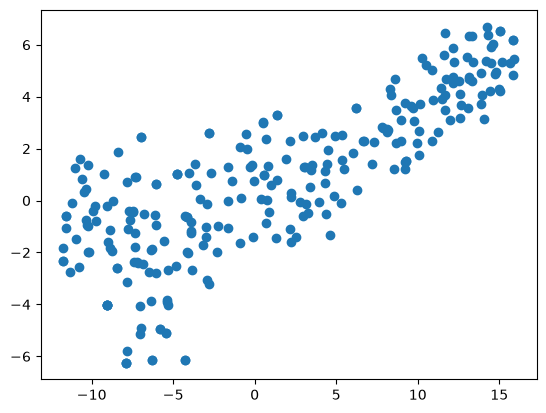

CPU times: user 27.3 s, sys: 7.28 ms, total: 27.3 s
Wall time: 848 ms


In [5]:
%%time

tsne = TSNE(n_components = 2, perplexity  = 50, random_state = 4, n_jobs = -1)
coords = tsne.fit_transform(search_place_vectors)

plt.scatter(
    x = coords[ : , 0],
    y = coords[ : , 1]
)
plt.show()

In [6]:
%%time

index = faiss.IndexFlatL2(search_place_vectors.shape[1])

index.add(search_place_vectors)
    
user_scores, ids = index.search(dt_faiss, k = 1)    


CPU times: user 6min 9s, sys: 53.7 s, total: 7min 2s
Wall time: 7.64 s


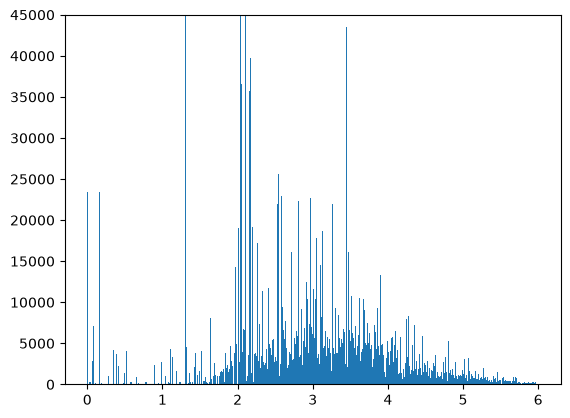

count    3.797622e+07
mean     2.963357e+00
std      1.517358e+00
min      0.000000e+00
25%      2.169403e+00
50%      2.891676e+00
75%      3.648488e+00
max      3.049772e+01
Name: user_scores, dtype: float64

CPU times: user 7.01 s, sys: 385 ms, total: 7.4 s
Wall time: 7.39 s


In [7]:
%%time

# Heavily skewed. Heavily concetrated in dispersed points.
plt.hist(
    x = user_scores.flatten(),
    bins = 10000,
    range = (0, 6)
)
plt.ylim(0, 45000)
plt.show()

df_merged_pd["user_scores"] = user_scores
display(df_merged_pd["user_scores"].describe()) # mean ~= median: symmetrical data

In [8]:
df_score_users = df_merged_pd.copy()

mean_user_score = df_score_users.groupby("msisdn").agg({"user_scores": "mean"})

IQR = mean_user_score.quantile(0.75) - mean_user_score.quantile(0.25)
#bound0 = (df_score_users["user_scores"].quantile(0.25) - 1.5 * IQR).iloc[0]
bound1 = (mean_user_score.quantile(0.75) + 1.5 * IQR).iloc[0]

df_score_users["user_scores"] = df_score_users.groupby("msisdn")["user_scores"].transform("mean")
df_underserved_users = df_score_users[df_score_users["user_scores"] > bound1]

display(df_underserved_users.head())
display(df_underserved_users.shape)
display(df_underserved_users.dtypes)
display(df_underserved_users.reset_index()["msisdn"].nunique())

,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned,log_ca,lognbj,user_scores
msisdn,,,,,,,,,,,,,,,,,,,,
261320207918,3010-31192,9,2026-05-28,Be,be 5000 new,5000.0,APP OM,Diana,Antsiranana II,Ankarongana,49.481730,-12.571214,3G,Rural,Couverture,Ambolombozobe,Diana,8.517393,2.302585,6.336738
261320274619,4410-44678,8,2026-05-30,Be,be 500 new,500.0,USSD,Boeny,Mahajanga I,Mahajanga I,46.300919,-15.715500,5G,Urbain,Couverture,MajungaLaCorniche,Boeny,6.216606,2.197225,6.099213
261320470215,1020-20802,10,2026-05-23,Be,ao tsara,500.0,IVR,Alaotra Mangoro,Moramanga,Amboasary,48.287804,-18.433750,3G,Peri-Urbain,Couverture,AmboasaryGara,Alaotra-Mangoro,6.216606,2.397895,6.076794
261320262231,6030-61112,59,2026-05-14,Be,be 2000 new,2000.0,IVR,Atsimo Andrefana,Toliara II,Mitsinjo Betanimena,43.687830,-23.350250,4G_TDD,Peri-Urbain,Densification,TulearAmpasikibo,Atsimo-Andrefana,7.601402,4.094345,6.214685
261320197632,4400-49041,10,2026-05-08,Be,be 2000 new,2000.0,IVR,Boeny,Marovoay,Tsararano,46.673061,-16.177817,3G,Rural,Couverture,MarovoayTsararano2,Boeny,7.601402,2.397895,6.747896


(583136, 20)

site_id                         str
nb_jours                      int64
date                 datetime64[ms]
Gamme_groupe                    str
Nom du forfait                  str
CA                          float64
Group_canal                     str
sig_region_name                 str
sig_district_name               str
sig_commune_name                str
x                           float64
y                           float64
Max_RAT                         str
Typologie                       str
Typologie site                  str
sig_nom_site                    str
region_cleaned                  str
log_ca                      float64
lognbj                      float64
user_scores                 float32
dtype: object

194296

In [9]:
def get_mode(x):
    return x.mode()[0]

df_underserved_users_gp = df_underserved_users.groupby("msisdn").agg(
    {
    "lognbj": "mean",
    "log_ca": "mean",
    "Group_canal": get_mode,
    "Max_RAT": get_mode,
    "Typologie": get_mode,
    "Typologie site": get_mode,
    "region_cleaned": get_mode
    }
)

df_underserved_users_gp.head()

,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned
msisdn,,,,,,,
261320103819,2.639057,6.667720,MAXIT,4G_FDD,Rural,Backbone et Couverture,Vakinankaratra
261320107679,0.693147,6.216606,IVR,4G+_TDD,Urbain,Couverture,Analanjirofo
261320116731,3.931826,8.430243,MAXIT,3G,Rural,Couverture,Atsimo-Atsinana
261320116828,1.945910,11.396403,MBC,4G_FDD,Urbain,Densification,Alaotra-Mangoro
261320119604,1.098612,7.713074,USSD,4G+_TDD,Urbain,Densification,Analamanga


In [10]:
t1 = time.time()

cols_to_scale = ["lognbj", "log_ca"]

df_num = imputer.transform(df_underserved_users_gp[cols_to_scale])


display(f"Imputing data took {time.time() - t1:.2f}s.")


t2 = time.time()

df_num_scaled = scaler.transform(df_num)

display(f"Scaling data took {time.time() - t2:.2f}s.")

t3 = time.time()

cols_to_encod = ["Group_canal", "Max_RAT", "Typologie", "Typologie site", "region_cleaned"]

df_cat = encoder.transform(df_underserved_users_gp[cols_to_encod])


display(f"Encoding data took {time.time() - t3:.2f}s.")

dt_faiss = np.concat([df_num_scaled, df_cat], axis = 1).astype(np.float32)
display(dt_faiss)
display(dt_faiss.shape)
display(dt_faiss.dtype)


'Imputing data took 0.01s.'

'Scaling data took 0.00s.'

'Encoding data took 0.23s.'

array([[-1.3748612 ,  0.12073469,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [-5.159549  , -0.5531036 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.1395019 ,  2.7534518 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-2.7229943 , -0.7101516 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-4.370942  , -0.6578023 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-5.159549  , -1.5854937 ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(194296, 43), dtype=float32)

(194296, 43)

dtype('float32')

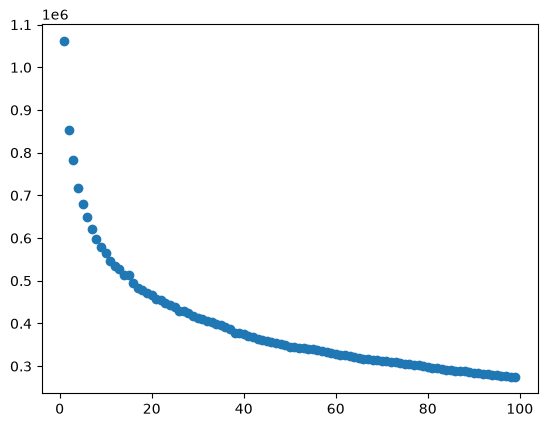

CPU times: user 10min 35s, sys: 3min 27s, total: 14min 2s
Wall time: 1min 53s


In [ ]:
%%time

k_values = range(1, 100)
# SSE from centroid
inertias = []
for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 4)
    kmeans.fit(dt_faiss)
    inertias.append(kmeans.inertia_)

plt.scatter(k_values, inertias, marker = "o")
plt.show()



In [22]:
optimal_k = 25
kmeans = KMeans(n_clusters = optimal_k, random_state = 4)
kmeans.fit(dt_faiss)
df_underserved_users_gp["labels"] = kmeans.labels_


for label, df in df_underserved_users_gp.groupby("labels"):
    display(df.describe(include = "all"))


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,7294.000000,7294.000000,7294,7294,7294,7294,7294,7294.0
unique,NaN,NaN,4,4,3,3,22,NaN
top,NaN,NaN,USSD,3G,Rural,Couverture,Atsimo-Andrefana,NaN
freq,NaN,NaN,7207,7206,6079,6002,1438,NaN
mean,0.937093,6.341524,NaN,NaN,NaN,NaN,NaN,0.0
std,0.261872,0.326579,NaN,NaN,NaN,NaN,NaN,0.0
min,0.693147,4.615121,NaN,NaN,NaN,NaN,NaN,0.0
25%,0.693147,6.216606,NaN,NaN,NaN,NaN,NaN,0.0
50%,1.098612,6.216606,NaN,NaN,NaN,NaN,NaN,0.0
75%,1.098612,6.216606,NaN,NaN,NaN,NaN,NaN,0.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,9441.000000,9441.000000,9441,9441,9441,9441,9441,9441.0
unique,NaN,NaN,5,5,3,2,14,NaN
top,NaN,NaN,IVR,4G+_FDD,Urbain,Densification,Diana,NaN
freq,NaN,NaN,9203,7678,8774,8184,3558,NaN
mean,1.586457,6.442205,NaN,NaN,NaN,NaN,NaN,1.0
std,0.341642,0.337180,NaN,NaN,NaN,NaN,NaN,0.0
min,1.098612,4.615121,NaN,NaN,NaN,NaN,NaN,1.0
25%,1.386294,6.216606,NaN,NaN,NaN,NaN,NaN,1.0
50%,1.609438,6.298828,NaN,NaN,NaN,NaN,NaN,1.0
75%,1.945910,6.678039,NaN,NaN,NaN,NaN,NaN,1.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,9109.000000,9109.000000,9109,9109,9109,9109,9109,9109.0
unique,NaN,NaN,4,4,3,3,22,NaN
top,NaN,NaN,USSD,4G_FDD,Urbain,Densification,Alaotra-Mangoro,NaN
freq,NaN,NaN,8911,9098,7653,6710,2060,NaN
mean,0.911951,6.251621,NaN,NaN,NaN,NaN,NaN,2.0
std,0.229593,0.307797,NaN,NaN,NaN,NaN,NaN,0.0
min,0.693147,4.615121,NaN,NaN,NaN,NaN,NaN,2.0
25%,0.693147,6.216606,NaN,NaN,NaN,NaN,NaN,2.0
50%,0.693147,6.216606,NaN,NaN,NaN,NaN,NaN,2.0
75%,1.098612,6.216606,NaN,NaN,NaN,NaN,NaN,2.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,10707.000000,10707.000000,10707,10707,10707,10707,10707,10707.0
unique,NaN,NaN,5,5,3,3,22,NaN
top,NaN,NaN,IVR,3G,Rural,Couverture,Sava,NaN
freq,NaN,NaN,5779,10517,10700,9988,2138,NaN
mean,2.132712,6.224957,NaN,NaN,NaN,NaN,NaN,3.0
std,0.192634,0.258043,NaN,NaN,NaN,NaN,NaN,0.0
min,1.386294,4.615121,NaN,NaN,NaN,NaN,NaN,3.0
25%,1.945910,6.216606,NaN,NaN,NaN,NaN,NaN,3.0
50%,2.197225,6.216606,NaN,NaN,NaN,NaN,NaN,3.0
75%,2.302585,6.216606,NaN,NaN,NaN,NaN,NaN,3.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,15434.000000,15434.000000,15434,15434,15434,15434,15434,15434.0
unique,NaN,NaN,4,3,3,2,22,NaN
top,NaN,NaN,IVR,3G,Rural,Couverture,Sava,NaN
freq,NaN,NaN,15370,15378,14178,14634,3481,NaN
mean,0.893594,6.519648,NaN,NaN,NaN,NaN,NaN,4.0
std,0.202726,0.355454,NaN,NaN,NaN,NaN,NaN,0.0
min,0.693147,4.615121,NaN,NaN,NaN,NaN,NaN,4.0
25%,0.693147,6.216606,NaN,NaN,NaN,NaN,NaN,4.0
50%,0.693147,6.447322,NaN,NaN,NaN,NaN,NaN,4.0
75%,1.098612,6.908755,NaN,NaN,NaN,NaN,NaN,4.0


...

,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,7970.000000,7970.000000,7970,7970,7970,7970,7970,7970.0
unique,NaN,NaN,5,3,2,2,20,NaN
top,NaN,NaN,IVR,4G_FDD,Rural,Couverture,Diana,NaN
freq,NaN,NaN,6028,7914,6822,7884,1488,NaN
mean,1.008835,6.513867,NaN,NaN,NaN,NaN,NaN,20.0
std,0.267833,0.357755,NaN,NaN,NaN,NaN,NaN,0.0
min,0.693147,4.615121,NaN,NaN,NaN,NaN,NaN,20.0
25%,0.693147,6.216606,NaN,NaN,NaN,NaN,NaN,20.0
50%,1.098612,6.412276,NaN,NaN,NaN,NaN,NaN,20.0
75%,1.098612,6.908755,NaN,NaN,NaN,NaN,NaN,20.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,6833.000000,6833.000000,6833,6833,6833,6833,6833,6833.0
unique,NaN,NaN,4,5,1,2,17,NaN
top,NaN,NaN,IVR,5G,Urbain,Couverture,Diana,NaN
freq,NaN,NaN,6634,2236,6833,6659,1558,NaN
mean,1.783421,6.410375,NaN,NaN,NaN,NaN,NaN,21.0
std,0.253770,0.337766,NaN,NaN,NaN,NaN,NaN,0.0
min,1.386294,4.615121,NaN,NaN,NaN,NaN,NaN,21.0
25%,1.609438,6.216606,NaN,NaN,NaN,NaN,NaN,21.0
50%,1.791759,6.216606,NaN,NaN,NaN,NaN,NaN,21.0
75%,1.945910,6.637106,NaN,NaN,NaN,NaN,NaN,21.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,5756.000000,5756.000000,5756,5756,5756,5756,5756,5756.0
unique,NaN,NaN,4,5,3,3,14,NaN
top,NaN,NaN,USSD,4G+_FDD,Urbain,Densification,Alaotra-Mangoro,NaN
freq,NaN,NaN,5614,4908,5349,3862,1139,NaN
mean,0.942208,6.326466,NaN,NaN,NaN,NaN,NaN,22.0
std,0.242732,0.338849,NaN,NaN,NaN,NaN,NaN,0.0
min,0.693147,4.615121,NaN,NaN,NaN,NaN,NaN,22.0
25%,0.693147,6.216606,NaN,NaN,NaN,NaN,NaN,22.0
50%,1.098612,6.216606,NaN,NaN,NaN,NaN,NaN,22.0
75%,1.098612,6.216606,NaN,NaN,NaN,NaN,NaN,22.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,7778.000000,7778.000000,7778,7778,7778,7778,7778,7778.0
unique,NaN,NaN,5,6,3,3,13,NaN
top,NaN,NaN,USSD,5G,Peri-Urbain,Couverture,Analamanga,NaN
freq,NaN,NaN,5590,2934,7320,5845,6512,NaN
mean,0.925240,6.280555,NaN,NaN,NaN,NaN,NaN,23.0
std,0.239258,0.334929,NaN,NaN,NaN,NaN,NaN,0.0
min,0.693147,4.615121,NaN,NaN,NaN,NaN,NaN,23.0
25%,0.693147,6.216606,NaN,NaN,NaN,NaN,NaN,23.0
50%,1.098612,6.216606,NaN,NaN,NaN,NaN,NaN,23.0
75%,1.098612,6.216606,NaN,NaN,NaN,NaN,NaN,23.0


,lognbj,log_ca,Group_canal,Max_RAT,Typologie,Typologie site,region_cleaned,labels
count,10112.000000,10112.000000,10112,10112,10112,10112,10112,10112.0
unique,NaN,NaN,5,4,3,2,22,NaN
top,NaN,NaN,IVR,3G,Rural,Couverture,Sava,NaN
freq,NaN,NaN,9902,9905,10070,9133,2491,NaN
mean,2.159756,6.813822,NaN,NaN,NaN,NaN,NaN,24.0
std,0.160831,0.228335,NaN,NaN,NaN,NaN,NaN,0.0
min,1.791759,6.291953,NaN,NaN,NaN,NaN,NaN,24.0
25%,2.079442,6.642992,NaN,NaN,NaN,NaN,NaN,24.0
50%,2.197225,6.908755,NaN,NaN,NaN,NaN,NaN,24.0
75%,2.302585,6.908755,NaN,NaN,NaN,NaN,NaN,24.0
